## Classification and Regression
- Supervised learning algorithms are typically divided into two categories: classification and regression. In this section, we will explore some widely used techniques

### k-nn regression
- K-NN Regression(K-최근접 이웃 회귀) 알고리즘은 주변의 가장 가까운 K개의 샘플을 통해 값을 예측

### Metrics
- $ R^2$ = 1 - ( Σᵢ (yᵢ - ŷᵢ)² ) / ( Σᵢ (yᵢ - ȳ)² )
    - yᵢ: 실제 값 (ground truth)
    - ŷᵢ: 모델의 예측 값
    - ȳ: 실제 값들의 평균
    - n: 데이터 수
- mean absolute error

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

plt.rcParams['font.family'] = ['DejaVu Sans', 'NanumGothic']

n_neighbors=1 [R-squared error: 0.99, mae: 22.69]
n_neighbors=5 [R-squared error: 0.99, mae: 19.16]
n_neighbors=10 [R-squared error: 0.97, mae: 39.24]


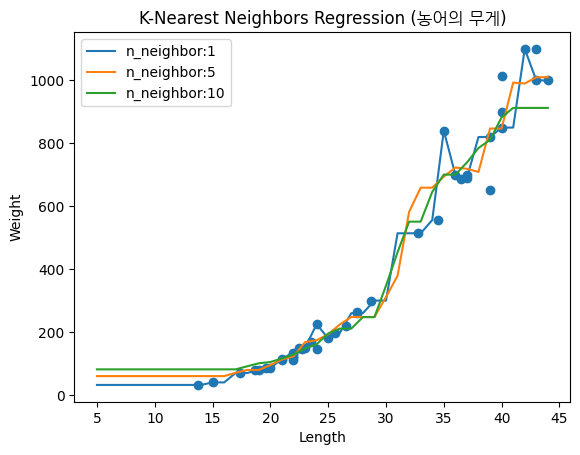

In [2]:
# 생선(농어)의 무게를 예측하자!

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

# reshaping is essential
train_input = train_input.reshape(-1, 1) #(42, 1)
test_input = test_input.reshape(-1, 1) #(14, 1)

# k-nn
knr = KNeighborsRegressor(
    n_neighbors=5, #default
    weights='uniform' #default
)

x = np.arange(5, 45).reshape(-1, 1)
for i, n in enumerate([1, 5, 10]):
    #train
    knr.n_neighbors = n
    knr.fit(train_input, train_target)
    #predict
    prediction = knr.predict(x)
    #test
    test_prediction = knr.predict(test_input)
    rse = knr.score(test_input, test_target)
    mae = mean_absolute_error(test_target, test_prediction)
    print(f'n_neighbors={n} [R-squared error: {rse:.2f}, mae: {mae:.2f}]')
    #plot
    plt.plot(x, prediction, label=f'n_neighbor:{n}')

plt.scatter(train_input, train_target)
plt.title('K-Nearest Neighbors Regression (농어의 무게)')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.show()

### k-nn regression 한계

- k-NN 회귀 모델을 사용하여 50cm인 농어의 무게를 예측하고 50cm의 농어의 데이터를 산점도(scatter)로 시각화하여 보자

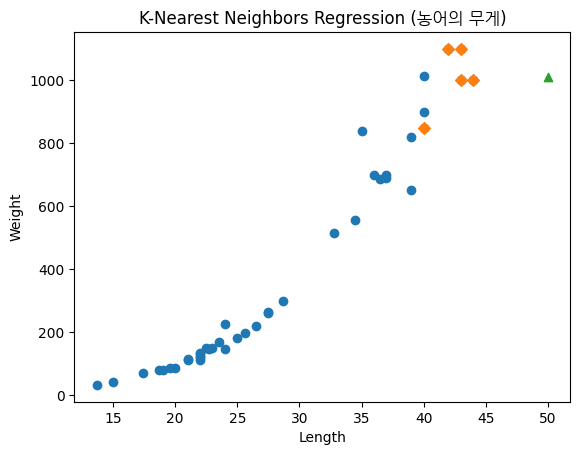

In [3]:
knr.n_neighbors = 5
knr.fit(train_input, train_target)

distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(50, knr.predict([[50]]), marker='^')
plt.title('K-Nearest Neighbors Regression (농어의 무게)')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

- K-NN은 주변 데이터를 기반으로 한다.
- 50cm의 농어 무게를 예측할 때 사용된 이웃의 데이터를 보면 모두 45cm 근처에서 나왔다. 따라서 50cm이상의 값은 정상적인 값이 나올수 없다.

### linear regression
- 선형회귀(linear regression)는 널리 사용되는 대표적인 회귀 알고리즘
- 특성이 하나인 어떤 직선을 학습하는 알고리즘

### Metrics
- $ R^2$ = 1 - ( Σᵢ (yᵢ - ŷᵢ)² ) / ( Σᵢ (yᵢ - ȳ)² )
    - yᵢ: 실제 값 (ground truth)
    - ŷᵢ: 모델의 예측 값
    - ȳ: 실제 값들의 평균
    - n: 데이터 수

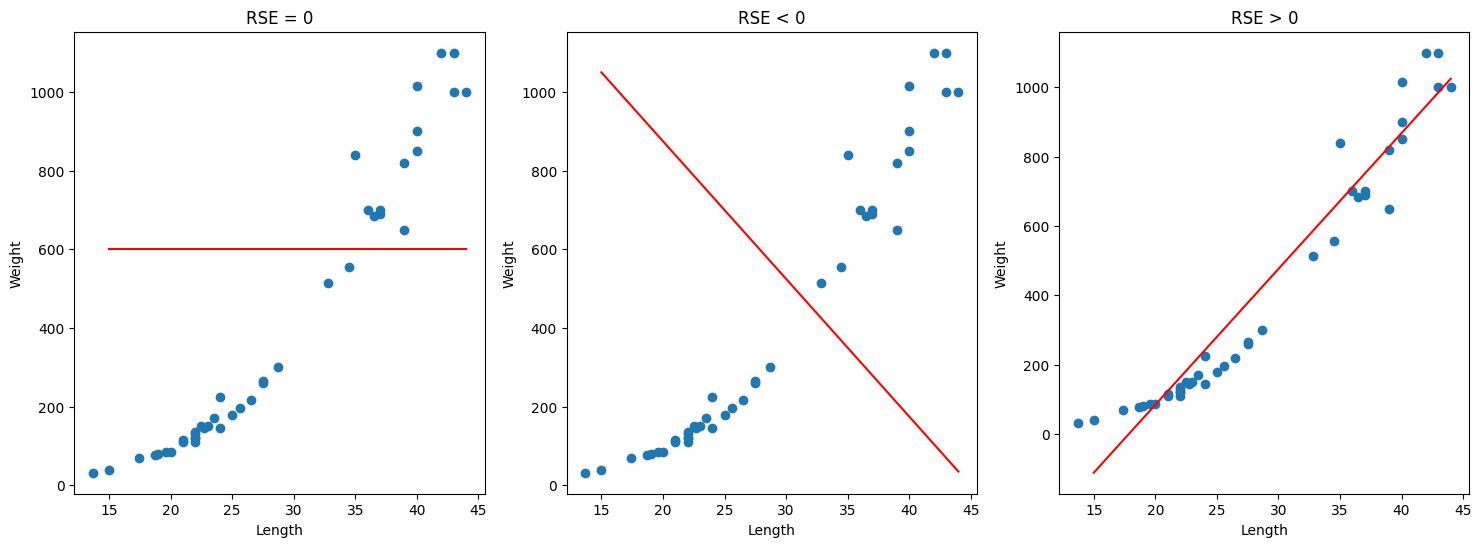

In [4]:
x = np.arange(15, 45)

fig, axs = plt.subplots(figsize=(18,6) , ncols=3 , nrows=1)

axs[0].scatter(train_input, train_target)
axs[0].plot(x, [600]*x.__len__(), color='red')
axs[0].set_title('RSE = 0')
axs[0].set_xlabel('Length')
axs[0].set_ylabel('Weight')

axs[1].scatter(train_input, train_target)
axs[1].plot(x, -35*x + 35*45, color='red')
axs[1].set_title('RSE < 0')
axs[1].set_xlabel('Length')
axs[1].set_ylabel('Weight')

axs[2].scatter(train_input, train_target)
axs[2].plot(x, 39.2*x - 700, color='red')
axs[2].set_title('RSE > 0')
axs[2].set_xlabel('Length')
axs[2].set_ylabel('Weight')

plt.show()

- 1은 모든 농어의 무게를 하나로 예측합니다. $ R^2$는 0에 가까운 값이 됩니다. 
- 2은 완전히 반대로 예측합니다. $ R^2$ 값이 음수가 될 수 있습니다. 
- 3은 가장 그럴싸한 직선입니다. 

coefficient: ['39.02'], intercept: -709.02


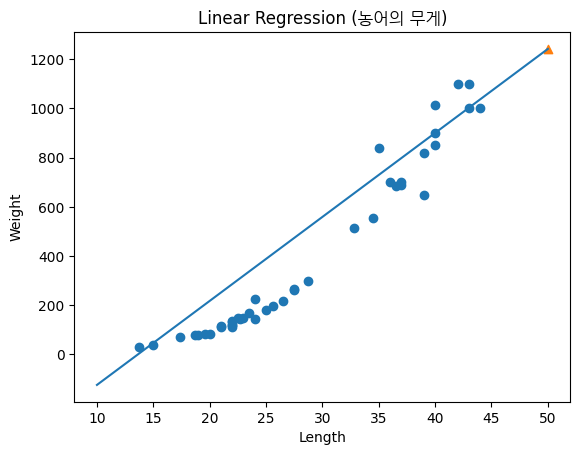

In [5]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

# pretty print for numy.ndarray
vec_format = np.vectorize(lambda x: f"{x:.2f}")
print(f'coefficient: {vec_format(lr.coef_)}, intercept: {lr.intercept_:.2f}')

plt.scatter(train_input, train_target)
plt.plot([10, 50], [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_])
plt.scatter(50, lr.predict([[50]]), marker='^')
plt.title('Linear Regression (농어의 무게)')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

- $ R^2$ 점수를 확인하자

In [6]:
print(f'Train R-squared error score: {lr.score(train_input, train_target):.4f}')
print(f'Test R-squared error score: {lr.score(test_input, test_target):.4f}')

Train R-squared error score: 0.9398
Test R-squared error score: 0.8248


### 다항 회귀 (Polynomial regression)

- 선형 회귀가 왼쪽 아래로 쭉 뻗어 있어 농어의 무게가 0g 이하로 나올 수 있는데, 현실에서는 있을 수 없는 일.
- 왼쪽 위로 조금 구부러진 곡선을 찾아보자!
- $y = ax^2+bx+c$

### Metrics
- $ R^2$ = 1 - ( Σᵢ (yᵢ - ŷᵢ)² ) / ( Σᵢ (yᵢ - ȳ)² )
    - yᵢ: 실제 값 (ground truth)
    - ŷᵢ: 모델의 예측 값
    - ȳ: 실제 값들의 평균
    - n: 데이터 수

In [7]:
def poly(m, x):
    y = m.intercept_
    for idx, coef in enumerate(m.coef_):
        y += m.coef_[-(idx+1)] * x**(idx+1)    
    return y

coefficient: ['-0.03' '3.55' '-90.59'], intercept: 709.95


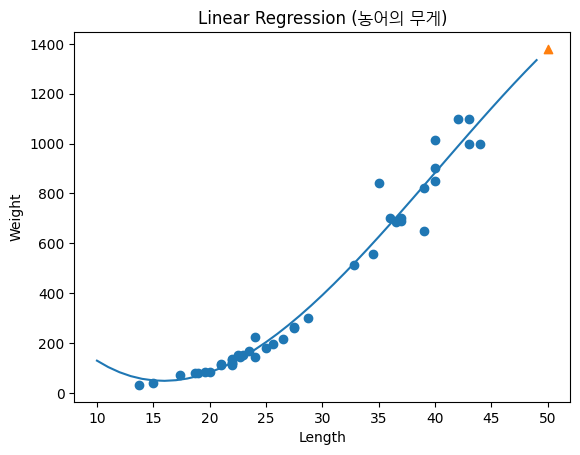

In [8]:
train_poly = np.column_stack((train_input ** 3, train_input ** 2, train_input)) # (42, 3)
test_poly = np.column_stack((test_input ** 3, test_input ** 2, test_input)) # (42, 3)

poly_lr = LinearRegression()
poly_lr.fit(train_poly, train_target)

print(f'coefficient: {vec_format(poly_lr.coef_)}, intercept: {poly_lr.intercept_:.2f}')

x = np.arange(10, 50)
plt.scatter(train_input, train_target)
plt.plot(x, poly(poly_lr, x))
plt.scatter([50], poly_lr.predict([[50**3, 50**2, 50]]), marker='^')
plt.title('Linear Regression (농어의 무게)')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

- $ R^2$ 점수를 확인하자

In [9]:
print(f'Train R-squared error score: {poly_lr.score(train_poly, train_target):.4f}')
print(f'Test R-squared error score: {poly_lr.score(test_poly, test_target):.4f}')

Train R-squared error score: 0.9729
Test R-squared error score: 0.9588


### 통계 패키지를 통한 선형회귀


In [10]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

y = perch_weight
X = sm.add_constant(perch_length)

linear_regression = sm.OLS(y, X)
fitted_model = linear_regression.fit()
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     612.8
Date:                Tue, 26 Nov 2024   Prob (F-statistic):           3.78e-31
Time:                        07:05:34   Log-Likelihood:                -336.24
No. Observations:                  56   AIC:                             676.5
Df Residuals:                      54   BIC:                             680.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -648.0776     43.705    -14.828      0.000    -735.702    -560.454
x1            36.9384      1.492     24.756      0.000      33.947      39.930
==============================================================================
Omnibus:                       14.223   Durbin-Watson:                   0.797
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.705
Skew:                           1.101   Prob(JB):                     0.000389
Kurtosis:                       4.373   Cond. No.                         96.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

* Dep. Variable : 목표변수를 나타낸다. 
* Model : 적합 모델을 나타낸다. OLS는 선형회귀의 또 다른 방법으로 ordinary least squares의 약어이다.
    *  잔차제곱합(RSS: Residual Sum of Squares)를 최소화하는 가중치 벡터를 구하는 방법이다.
* Method : 파라미터 적합 방법을 나타낸다. 최소제곱 방법은 고전적인 계산 방법이다. 
* No. Observations : 사용된 관찰 개수를 나타낸다. 
* DF Residuals : 잔차의 자유도를 나타낸다. 관찰 개수에서 파라미터의 수를 뺀 값 
* DF Model : 모델에서 추정하는 파라미터의 개수. 상수항은 제외한다. 

----
* R-Squared : 결정계수로, 회귀가 단순평균과 관련해 얼마나 잘 수행했는지 나타낸다. 
* Adj R-Squared : 모델의 파라미터 개수와 모델 구축에 도움이 된 관찰 개수에 따라 조정된 결정계수를 나타낸다. 
* F-statistic : 통계적 관점에서 볼 때 편향을 제외한 모든 계수가 0과 다른지 나타내는 척도. 간단히 말해서 회귀가 단순평균보다 나은지 보여준다. 
* Prob(F-statistic) : 실제로 사용된 관찰로 인해 운 좋게 F-statistic에 도달할 확률을 나타내며, p-value라고 한다. 그 값이 충분히 낮다면 회귀가 단순평균보다 휠씬 더 좋다는 것을 확신할 수 있다. 
* AIC : 관찰 개수와 모델 자체의 복잡성을 기반으로 모델을 평가하는 점수. AIC 점수가 낮을수록 더 좋다ㅓ. 다양한 모델을 비교하여 통계 변수를 선택할 때 매우 우용한다. 
* BIC : AIC와 유사하게 작동하나 파라미터가 많은 모델에 대해 더 많은 단점을 갖는다. 

----
* coef : 추정계수를 나타낸다.
* std err: 계수 추정치의 표준오차로, 값이 크면 클수록 계수 추정치의 불확실성이 높아진다. 
* t : t-value으로 계수의 참값이 0과 다른지를 나타내는 척도 
: P > |t| : 계수가 0이 아닐 확률을 나타내는 p값 
* Conf. Interval : : 다른 관찰값과 추정계수가 다를 수 있는 모든 가능성에 대해 계수의 상한값과 하한값 모두 95%로 고려함을 의미힌다. 
* 데이터 과학 관점에서는 대부분 응답변수를 예측하는 동안 회귀가 작동하는지 여부를 확인하는 데에만 주로 관심이 있기 때문에 t-test와 신뢰 영역은 별로 중요하게 생각하지 않는다. 따라서 coef 값과 표준오차에만 초점을 맞출 것이다. 

-------------
* Skewnewss(비대칭도) : 평균 주위 잔차의 대칭을 측정한 것으로, 대칭 분포 잔차의 경우에는 값이 0에 가까워야 한다. 양수값은 오른쪽으로 긴 꼬리를 나타내고, 음수값은 왼쪽으로 긴 꼬리를 나타낸다. 
* Kurtosis(첨도) : 잔차의 분포 모양을 측정한 것으로, 종 모양의 분포이면 0의 값을 갖는다. 음수값은 아주 평평한 분포이고, 양수값은 매우 뽀죡한 분포를 갖는다. 
* Omnibus : 비대칭도와 첨도를 결합한 통계 테스트 
* Prob(Omnibus) : 옴니버스 통계를 확률로 변환 
* Jarque-Bera : 비대칭도와 첨도의 또 다른 테스트
* Prob(JB) : JB 통계를 확률로 변환한 것 
* Durbin-Watson : 잔차 사이의 상관관계 여부를 나타내는 테스트. 시간 기반 데이터 분석과 관련이 있다. 
* Cond No : 다중공선성(multicollinearity)에 대한 테스트. 여러 개의 예측변수를 작업할 때 사용 
----------
* 많은 통계 테스트와 정보를 포함하는 꽤 긴 일련의 표를 얻을 수 있다. 분석 목적이 통계적인 것이 아니라면 실제로 이런 아웃풋이 모두 필요한 것은 아니다. 
* 데이터 과학은 주로 통계적 문제에 대해 형식적으로 정확한 사양이 아닌, 실제 데이터를 예측하는 실제 모델과 관련이 있다. 
* 그럼에도 불구하고 일부는 여전히 좋은 모델을 만들기 위해서 유용하며 주요 수치에 대한 통찰력을 제공할 것이다. 

### 다른 회귀 방법

### Metrics
- $ R^2$ = 1 - ( Σᵢ (yᵢ - ŷᵢ)² ) / ( Σᵢ (yᵢ - ȳ)² )
    - yᵢ: 실제 값 (ground truth)
    - ŷᵢ: 모델의 예측 값
    - ȳ: 실제 값들의 평균
    - n: 데이터 수

In [11]:
import pandas as pd
from pandas import DataFrame, Series
from numpy.random import normal
import warnings
# warnings.filterwarnings(action='ignore')

def create_dataset(num):
    x = float(0)/float(num-1)
    y = np.sin(2*np.pi*x) + normal(scale=0.3)
    dataset = DataFrame({
        'x' : [x],
        'y' : [y]
    })
    
    for i in range(1, num):
        x = float(i)/float(num-1)
        y = np.sin(2*np.pi*x) + normal(scale=0.3)
        tmp = DataFrame({
            'x' : [x],
            'y' : [y]
        })
        dataset = pd.concat([dataset, tmp], ignore_index=True)

    return dataset

def rms_error(dataset, f):
    err = 0.0
    for index, line in dataset.iterrows():
        x, y = line.x, line.y
        err += 0.5 * (y - f(x))**2
    return np.sqrt(2 * err / len(dataset))

def resolve(dataset, m):
    t = dataset.y
    phi = DataFrame()
    for i in range(0,m+1):
        p = dataset.x**i
        p.name="x**%d" % i
        phi = pd.concat([phi,p], axis=1)
    tmp = np.linalg.inv(np.dot(phi.T, phi))
    ws = np.dot(np.dot(tmp, phi.T), t)

    def f(x):
        y = 0
        for i, w in enumerate(ws):
            y += w * (x ** i)
        return y
    return (f, ws)

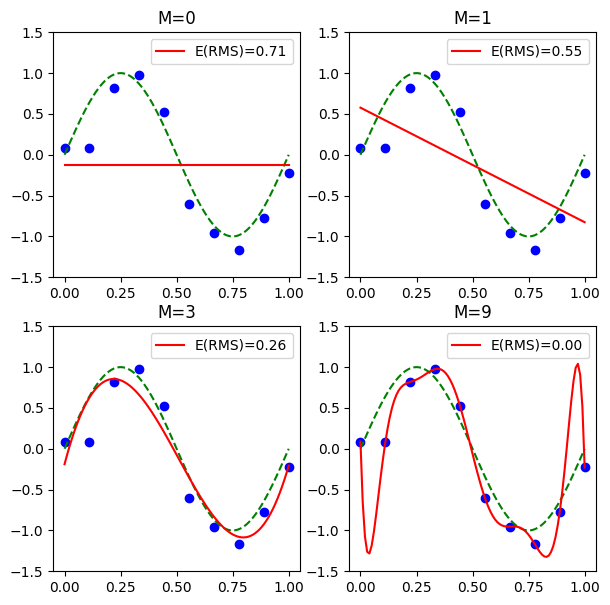

In [12]:
'''
경고 메시지에 나오는 "minus sign" 문자(−)는 대시(-)와 비슷한 역할을 하는 글자입니다. 
이를 해결하려면, 그래프 제목이나 레이블에서 해당 문자를 대체하는 방법도 고려할 수 있습니다. 
예를 들어, - 대신 −를 사용할 수 있도록 수동으로 수정할 수 있습니다.

'''
plt.rcParams['font.family'] = ['DejaVu Sans', 'NanumGothic']

N=10 # N > 0   
M=[0,1,3,9]  
train_set = create_dataset(N)
test_set = create_dataset(N)
df_ws = DataFrame()


fig = plt.figure(figsize=(7, 7))
for c, m in enumerate(M):
    f, ws = resolve(train_set, m)
    tmp = DataFrame({
        f"M={m}" : ws
    })
    df_ws = pd.concat([df_ws, tmp])

    subplot = fig.add_subplot(2,2,c+1)
    subplot.set_xlim(-0.05,1.05)
    subplot.set_ylim(-1.5,1.5)
    subplot.set_title("M=%d" % m)

    
    subplot.scatter(train_set.x, train_set.y, marker='o', color='blue')

    
    linex = np.linspace(0,1,101)
    liney = np.sin(2*np.pi*linex)
    subplot.plot(linex, liney, color='green', linestyle='--')

    
    linex = np.linspace(0,1,101)
    liney = f(linex)
    label = "E(RMS)=%.2f" % rms_error(train_set, f)
    subplot.plot(linex, liney, color='red', label=label)
    subplot.legend(loc=1)
    fig.show()

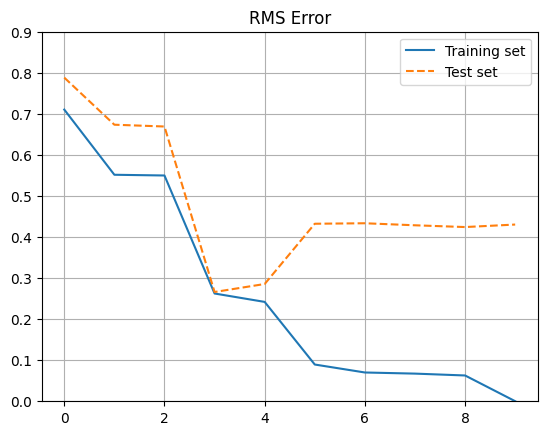

In [13]:
f, ws = resolve(train_set, 0)
train_error = rms_error(train_set, f)
test_error = rms_error(test_set, f)
df = DataFrame({
    'Training set' : [train_error],
    'Test set' : [test_error]
})

for m in range(1,10):
    f, ws = resolve(train_set, m)
    train_error = rms_error(train_set, f)
    test_error = rms_error(test_set, f)
    tmp = DataFrame({
        'Training set' : [train_error],
        'Test set' : [test_error]
    })
    df = pd.concat([df, tmp], ignore_index=True)
df.plot(title='RMS Error', style=['-','--'], grid=True, ylim=(0,0.9))
plt.show()